# 二阶龙格-库塔法（RK2）求解一维简谐振子

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月22日

例 3 的思考①留了一个问题：把 RK2 用于力随状态变化的简谐振子，还精确吗？本例动手回答。简谐振子是"最好算"的非平凡系统：有初等函数解析解，而且方程是线性的——我们将看到，连**数值误差本身都能用公式精确预言**。

运动方程（$\omega_0 = \sqrt{k/m}$ 为固有角频率）：

$$
m\ddot{x} = -kx
\qquad\Longleftrightarrow\qquad
\frac{dx}{dt} = v, \quad \frac{dv}{dt} = -\omega_0^2 x
$$

解析解 $x(t) = x_0\cos\omega_0 t + \dfrac{v_0}{\omega_0}\sin\omega_0 t$；本例取 $x_0 = 1,\ v_0 = 0,\ k = m = 1$，即 $x = \cos t$。

**总机械能**

$$
E = \tfrac{1}{2}mv^2 + \tfrac{1}{2}kx^2
$$

在真实运动中严格守恒；速度相空间 $(x, v)$ 中轨迹是过初值的椭圆（本例参数下为半径 1 的圆）。

**RK2（中点形式）**：先走半步到中点、估出中点斜率，再用它走整步——每步计算**两次**右端。代入振子：

$$
v_{n+\frac{1}{2}} = v_n - \tfrac{h}{2}\,\omega_0^2 x_n, \qquad
x_{n+\frac{1}{2}} = x_n + \tfrac{h}{2}\,v_n
$$

$$
x_{n+1} = x_n + h\,v_{n+\frac{1}{2}}, \qquad
v_{n+1} = v_n - h\,\omega_0^2 x_{n+\frac{1}{2}}
$$

**运行之前，先把你的预测写下来**：

1. 自由落体中 RK2 精确到机器精度；简谐振子的力 $-\omega_0^2 x$ 随状态变化——RK2 还精确吗？误差在什么量级？
2. 能量漂移比欧拉法慢多少？它随时间如何增长——能写成公式吗？
3. 数值解的振动周期比真实周期偏大还是偏小？

带着预测运行下面的代码，逐条对照。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_oscillator(x0, v0, k, m, h, n_steps):
    """前向欧拉法求解简谐振子 dx/dt = v, dv/dt = -(k/m) x
    返回时间、位置、速度数组（长度 n_steps + 1）"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        v[n + 1] = v[n] - h * (k / m) * x[n]
        x[n + 1] = x[n] + h * v[n]
    return t, x, v


def rk2_midpoint_oscillator(x0, v0, k, m, h, n_steps):
    """RK2 中点法求解简谐振子：半步预估中点状态，再用中点斜率走整步"""
    t = np.arange(n_steps + 1) * h
    x = np.empty(n_steps + 1)
    v = np.empty(n_steps + 1)
    x[0], v[0] = x0, v0
    for n in range(n_steps):
        v_mid = v[n] - 0.5 * h * (k / m) * x[n]     # 中点速度
        x_mid = x[n] + 0.5 * h * v[n]               # 中点位置
        x[n + 1] = x[n] + h * v_mid                 # 用中点斜率走整步
        v[n + 1] = v[n] - h * (k / m) * x_mid
    return t, x, v


# 参数（标准算例）
x0, v0 = 1.0, 0.0            # 初始位置 (m)、初始速度 (m/s)
k = 1.0                      # 劲度系数 (N/m)
m = 1.0                      # 质量 (kg)
om0 = np.sqrt(k / m)         # 固有角频率 (rad/s)
T0 = 2 * np.pi / om0         # 固有周期 (s)
h = 0.1                      # 时间步长 (s)
t_end = 30.0                 # 总时间 (s)
z = om0 * h                  # 无量纲步长

n_steps = int(t_end / h)
t, x_euler, v_euler = forward_euler_oscillator(x0, v0, k, m, h, n_steps)
t, x_rk2, v_rk2 = rk2_midpoint_oscillator(x0, v0, k, m, h, n_steps)
x_exact = x0 * np.cos(om0 * t) + v0 / om0 * np.sin(om0 * t)
v_exact = -x0 * om0 * np.sin(om0 * t) + v0 * np.cos(om0 * t)

# 总机械能：E = 1/2 m v^2 + 1/2 k x^2
E_euler = 0.5 * m * v_euler**2 + 0.5 * k * x_euler**2
E_rk2   = 0.5 * m * v_rk2**2 + 0.5 * k * x_rk2**2
E0 = 0.5 * m * v0**2 + 0.5 * k * x0**2

print(f'固有周期 T0 = {T0:.4f} s；无量纲步长 z = ω0·h = {z:.2f}，共 {n_steps} 步')
print(f'每步能量放大比（理论，下一节推导）：欧拉法 1 + z^2 = {1 + z**2:.4f}，RK2 1 + z^4/4 = {1 + z**4 / 4:.6f}')
print()
print(f'{"":16}{"RK2":>16}{"前向欧拉":>16}')
print(f'{"末能量 (J)":16}{E_rk2[-1]:>16.6f}{E_euler[-1]:>16.4f}')
print(f'{"末能量放大倍数":16}{E_rk2[-1] / E0:>16.6f}{E_euler[-1] / E0:>16.4f}')
print(f'{"理论放大倍数":16}{(1 + z**4 / 4)**n_steps:>16.6f}{(1 + z**2)**n_steps:>16.4f}')
print(f'{"末能量漂移 (J)":16}{E_rk2[-1] - E0:>16.3e}{E_euler[-1] - E0:>16.3e}')

固有周期 T0 = 6.2832 s；无量纲步长 z = ω0·h = 0.10，共 300 步
每步能量放大比（理论，下一节推导）：欧拉法 1 + z^2 = 1.0100，RK2 1 + z^4/4 = 1.000025

                             RK2            前向欧拉
末能量 (J)                 0.503764          9.8942
末能量放大倍数                 1.007528         19.7885
理论放大倍数                  1.007528         19.7885
末能量漂移 (J)              3.764e-03       9.394e+00


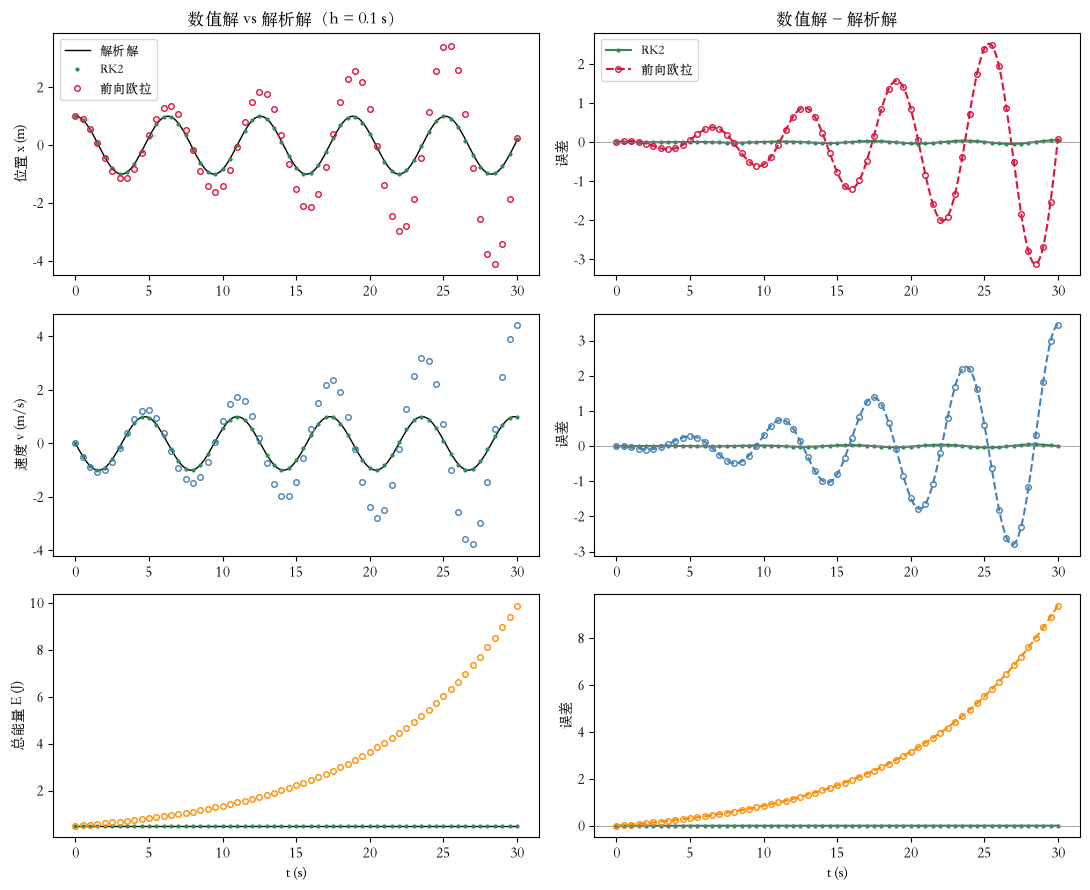

In [3]:
fig, axs = plt.subplots(3, 2, figsize=(11, 9))

rows = [
    ('位置 x (m)', x_exact, x_rk2, x_euler, 'crimson'),
    ('速度 v (m/s)', v_exact, v_rk2, v_euler, 'steelblue'),
    ('总能量 E (J)', np.full_like(t, E0), E_rk2, E_euler, 'darkorange'),
]

for i, (ylabel, y_ref, y_rk, y_eu, color) in enumerate(rows):
    # 左列：数值解 vs 解析解
    ax = axs[i, 0]
    ax.plot(t, y_ref, 'k-', lw=1, label='解析解')
    ax.plot(t, y_rk, '.', color='seagreen', ms=4, markevery=5, label='RK2')
    ax.plot(t, y_eu, 'o', color=color, ms=4, mfc='none', markevery=5, label='前向欧拉')
    ax.set_ylabel(ylabel)
    if i == 0:
        ax.set_title(f'数值解 vs 解析解（h = {h} s）')
        ax.legend(fontsize=9, loc='upper left')

    # 右列：误差
    ax = axs[i, 1]
    ax.plot(t, y_rk - y_ref, '.-', color='seagreen', ms=4, markevery=5, label='RK2')
    ax.plot(t, y_eu - y_ref, 'o--', color=color, ms=4, mfc='none', markevery=5, label='前向欧拉')
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_ylabel('误差')
    if i == 0:
        ax.set_title('数值解 − 解析解')
        ax.legend(fontsize=9, loc='upper left')

for ax in axs[-1]:
    ax.set_xlabel('t (s)')

fig.tight_layout()
fig.savefig('outputs/4_simple_oscillator_rk2_main.pdf')
plt.show()

**对照预测**：

1. **不精确，但误差小**：RK2 末位置误差约 $5\times10^{-2}$（欧拉法已累积到 3.1，相位面目全非）。RK2 的误差主要是**相位漂移**——误差曲线整体缓慢滑动，振幅误差极小。
2. **能量漂移**：RK2 末能量 0.50376 J（相对漂移 +0.75%），欧拉法 9.89 J（放大近 20 倍）——慢了约 2500 倍。更妙的是打印显示 RK2 的末放大倍数与理论值 $(1+z^4/4)^{300}$ **逐位相同**：能量按"每步乘固定比例"的指数律增长。这不是巧合，下一节推导。
3. 周期偏大还是偏小？上面的图还看不出来——留到收敛性一节用周期测量回答。

速度相空间里，解析轨迹是半径 1 的圆。欧拉法的轨迹我们熟悉：逐渐外旋的螺旋。RK2 的螺旋有多"陡"？运行对照。

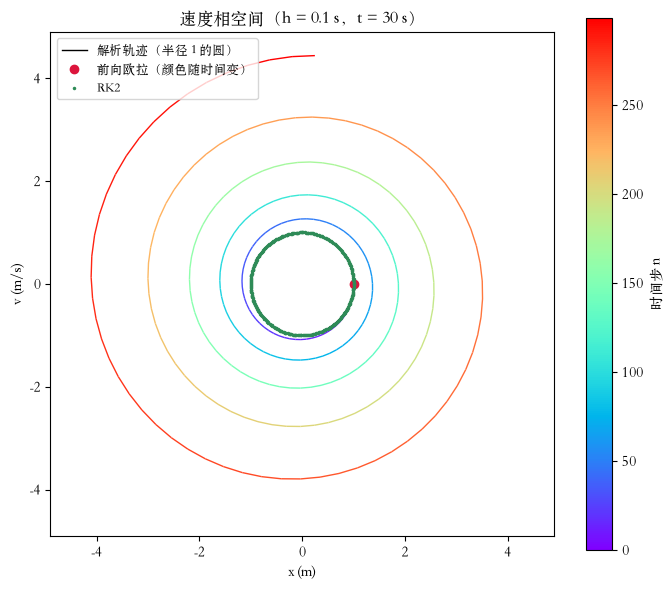

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

# 解析轨迹：圆
th_c = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(th_c), np.sin(th_c), 'k-', lw=1, label='解析轨迹（半径 1 的圆）')

# 前向欧拉：随时间变色的外旋螺旋
pts = np.array([x_euler, v_euler]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', array=np.arange(len(segs)), lw=1)
ax.add_collection(lc)
ax.plot(x_euler[0], v_euler[0], 'o', color='crimson', label='前向欧拉（颜色随时间变）')

# RK2：几乎闭合的圆
ax.plot(x_rk2, v_rk2, '.', color='seagreen', ms=3, label='RK2')

ax.set_xlabel('x (m)')
ax.set_ylabel('v (m/s)')
ax.set_aspect('equal')
ax.set_xlim(-4.9, 4.9)
ax.set_ylim(-4.9, 4.9)
ax.set_title(f'速度相空间（h = {h} s，t = {t_end:.0f} s）')
ax.legend(fontsize=9, loc='upper left')
fig.colorbar(lc, ax=ax, label='时间步 n')
fig.tight_layout()
fig.savefig('outputs/4_simple_oscillator_rk2_phase.pdf')
plt.show()

## 为什么漂移可以精确预言？——线性系统的特征值

简谐振子是**线性**系统：RK2 的每一步都是同一个矩阵作用在状态向量上。记 $z = \omega_0 h$，更新公式可以写成

$$
\begin{pmatrix} x_{n+1} \\ v_{n+1} \end{pmatrix} =
\underbrace{\begin{pmatrix} 1 - z^2/2 & h \\ -\omega_0^2 h & 1 - z^2/2 \end{pmatrix}}_{M}
\begin{pmatrix} x_n \\ v_n \end{pmatrix},
\qquad
\begin{pmatrix} x_n \\ v_n \end{pmatrix} = M^n \begin{pmatrix} x_0 \\ v_0 \end{pmatrix}
$$

一切都由 $M$ 的特征值决定：

$$
\lambda_\pm = 1 - \frac{z^2}{2} \pm \mathrm{i}z
\qquad\Longrightarrow\qquad
|\lambda|^2 = \left(1 - \frac{z^2}{2}\right)^2 + z^2 = 1 + \frac{z^4}{4}
$$

$z^2$ 项恰好抵消——$|\lambda|^2$ **精确地**等于 $1 + z^4/4$，一个近似都没有。本例取 $k = m = 1$ 时，$M$ 是"伸缩 + 旋转"的保形矩阵，任意状态的能量每一步都严格乘以 $|\lambda|^2$：

$$
E_n = E_0\left(1 + \frac{z^4}{4}\right)^n
$$

打印的理论值正是它——数值能量逐位落在公式上。前向欧拉法同理（矩阵 $\begin{pmatrix} 1 & h \\ -\omega_0^2 h & 1 \end{pmatrix}$，特征值 $1 \pm \mathrm{i}z$）：

$$
E_n = E_0\,(1 + z^2)^n
$$

**两条律的对比**：

- 每单位时间的增长率：欧拉 $\approx \omega_0^2 h$（∝h），RK2 $\approx \omega_0^4 h^3/4$（∝h³）——步长减半，欧拉慢一半，RK2 慢 8 倍；
- 但 $|\lambda| > 1$ 对**任何** $h > 0$ 都成立：RK2 对振子**不存在稳定步长**——它只是漂得慢，不是不漂。

RK2 系列至此的图景：

| 系统 | 力的特点 | RK2 的表现 |
| ---- | ---- | ---- |
| 自由落体（例 3） | 常力 | 精确到机器精度（长时间仅剩舍入级漂移） |
| 简谐振子（本例） | 线性变力 | 漂移律 $E_n = E_0(1+z^4/4)^n$ 可以**解析导出** |
| 大振幅单摆（下一例） | 非线性 | 解析武器失效，误差与漂移只能数值测量 |

线性让误差本身变得可解——这正是本例的价值。下一例将看到，非线性如何夺走这份红利。

## 收敛性：周期误差与能量漂移

解析律给出了两条可检验的预言。步长每次减半：$h = 0.2,\ 0.1,\ 0.05,\ 0.025,\ 0.0125$ s。

- **周期误差**：让数值解跑 8 个固有周期，用 $x$ 的过零时刻（线性插值）测出数值周期，看 $\Delta T = T_\text{数值} - T_0$；
- **能量漂移**：固定 $t = 30$ s，看 $|E_\text{末} - E_0|$。

**预测**：各自的收敛阶是多少？两种方法的周期误差同号还是反号？

带符号周期误差 ΔT = T_数值 − T0（s）：
       h          前向欧拉           RK2         理论 欧拉        理论 RK2
     0.2     8.280e-02    -4.110e-02     8.378e-02    -4.189e-02
     0.1     2.089e-02    -1.042e-02     2.094e-02    -1.047e-02
    0.05     5.233e-03    -2.615e-03     5.236e-03    -2.618e-03
   0.025     1.309e-03    -6.543e-04     1.309e-03    -6.545e-04
  0.0125     3.272e-04    -1.636e-04     3.272e-04    -1.636e-04
相邻比值（步长减半）：
  周期误差 欧拉: 3.96  3.99  4.00  4.00
  周期误差 RK2 : 3.94  3.98  4.00  4.00
  能量漂移 欧拉: 19.05  5.41  3.11  2.45
  能量漂移 RK2 : 8.21  8.03  8.00  8.00


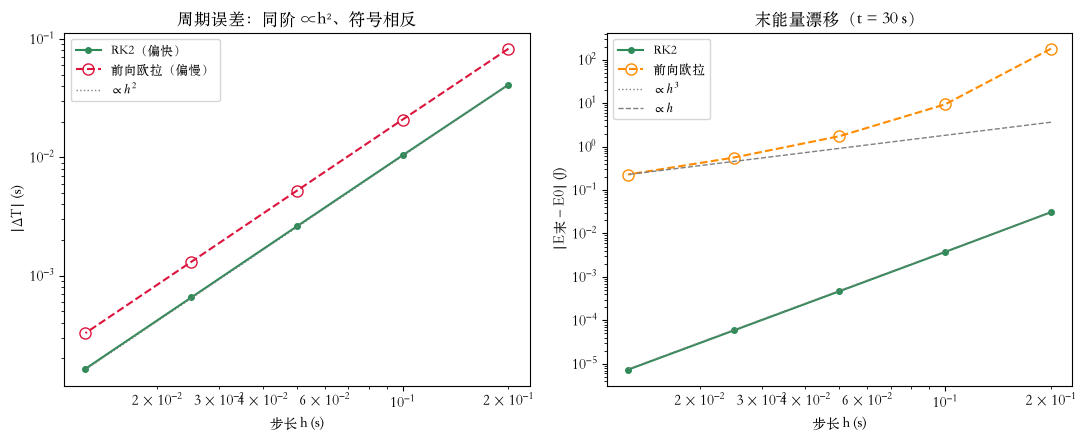

In [5]:
h_list = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])


def measure_period(solver, h_i, n_periods=8):
    """跑 n_periods 个固有周期，用 x 的过零时刻（线性插值）测数值周期"""
    _, x_num, _ = solver(x0, v0, k, m, h_i, int(n_periods * T0 / h_i))
    idx = np.where(np.diff(np.sign(x_num)) != 0)[0]
    frac = x_num[idx] / (x_num[idx] - x_num[idx + 1])
    t_cross = (idx + frac) * h_i
    return 2 * (t_cross[-1] - t_cross[0]) / (len(t_cross) - 1)


p_err = {'rk2': [], 'euler': []}
drift_h = {'rk2': [], 'euler': []}
for h_i in h_list:
    _, x_eu_i, v_eu_i = forward_euler_oscillator(x0, v0, k, m, h_i, int(t_end / h_i))
    _, x_rk_i, v_rk_i = rk2_midpoint_oscillator(x0, v0, k, m, h_i, int(t_end / h_i))
    drift_h['euler'].append(abs(0.5 * m * v_eu_i[-1]**2 + 0.5 * k * x_eu_i[-1]**2 - E0))
    drift_h['rk2'].append(abs(0.5 * m * v_rk_i[-1]**2 + 0.5 * k * x_rk_i[-1]**2 - E0))
    p_err['euler'].append(measure_period(forward_euler_oscillator, h_i) - T0)
    p_err['rk2'].append(measure_period(rk2_midpoint_oscillator, h_i) - T0)

p_err = {key: np.array(val) for key, val in p_err.items()}
drift_h = {key: np.maximum(np.array(val), 1e-18) for key, val in drift_h.items()}

print('带符号周期误差 ΔT = T_数值 − T0（s）：')
print(f'{"h":>8}{"前向欧拉":>14}{"RK2":>14}{"理论 欧拉":>14}{"理论 RK2":>14}')
for h_i, a, b in zip(h_list, p_err['euler'], p_err['rk2']):
    print(f'{h_i:>8}{a:>14.3e}{b:>14.3e}{T0 * h_i**2 / 3:>14.3e}{-T0 * h_i**2 / 6:>14.3e}')
print('相邻比值（步长减半）：')
print('  周期误差 欧拉:', '  '.join(f'{a / b:.2f}' for a, b in zip(p_err['euler'][:-1], p_err['euler'][1:])))
print('  周期误差 RK2 :', '  '.join(f'{a / b:.2f}' for a, b in zip(p_err['rk2'][:-1], p_err['rk2'][1:])))
print('  能量漂移 欧拉:', '  '.join(f'{a / b:.2f}' for a, b in zip(drift_h['euler'][:-1], drift_h['euler'][1:])))
print('  能量漂移 RK2 :', '  '.join(f'{a / b:.2f}' for a, b in zip(drift_h['rk2'][:-1], drift_h['rk2'][1:])))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# (a) 周期误差：同阶 ∝h²，符号相反（RK2 恰为一半）
ax1.loglog(h_list, np.abs(p_err['rk2']), '.-', color='seagreen', ms=8, label='RK2（偏快）')
ax1.loglog(h_list, np.abs(p_err['euler']), 'o--', color='crimson', ms=8, mfc='none', label='前向欧拉（偏慢）')
ax1.loglog(h_list, np.abs(p_err['rk2'][0]) * (h_list / h_list[0])**2,
           ':', color='gray', lw=1, label=r'$\propto h^2$')
ax1.set_xlabel('步长 h (s)')
ax1.set_ylabel('|ΔT| (s)')
ax1.set_title('周期误差：同阶 ∝h²、符号相反')
ax1.legend(fontsize=9)

# (b) 能量漂移：阶数的分野
ax2.loglog(h_list, drift_h['rk2'], '.-', color='seagreen', ms=8, label='RK2')
ax2.loglog(h_list, drift_h['euler'], 'o--', color='darkorange', ms=8, mfc='none', label='前向欧拉')
ax2.loglog(h_list, drift_h['rk2'][0] * (h_list / h_list[0])**3,
           ':', color='gray', lw=1, label=r'$\propto h^3$')
ax2.loglog(h_list, drift_h['euler'][-1] * (h_list / h_list[-1]),
           '--', color='gray', lw=1, label=r'$\propto h$')
ax2.set_xlabel('步长 h (s)')
ax2.set_ylabel('|E末 − E0| (J)')
ax2.set_title('末能量漂移（t = 30 s）')
ax2.legend(fontsize=9)

fig.tight_layout()
fig.savefig('outputs/4_simple_oscillator_rk2_convergence.pdf')
plt.show()

**读图**：

1. **周期误差（左）**：两种方法落在**同一条** ∝h² 直线上（相邻比值均 ≈ 4.00），阶数相同；但打印的带符号值显示**符号相反**——欧拉法偏慢（$\Delta T > 0$），RK2 偏快（$\Delta T < 0$），大小恰为一半。特征值里早写着：数值角频率是特征值的辐角，$\arg\lambda = \arctan z = z - z^3/3$（欧拉，偏慢）对比 $\arg\lambda = \arctan\dfrac{z}{1 - z^2/2} = z + z^3/6$（RK2，偏快）。
2. **能量漂移（右）**：这才是阶数的分野。RK2 严格压在 ∝h³ 参考线上（相邻比值 8.00）；欧拉法连 ∝h 都守不住——小步长端贴着参考线，大步长端急剧抬高（相邻比值 19 → 2.5）：固定 30 s 内漂移被 $(1+z^2)^n$ 的指数放大接管。

## 长时间：解析律的终极检验

$E_n = E_0(1+z^4/4)^n$ 对**每一步**严格成立，理应在大 $n$ 时继续精确。把步长加大到 $h = 0.4$ s（$z = 0.4$，每周期仅约 16 步），跑 $t = 150$ s ≈ 24 个周期，让能量放大 10 倍以上；此时欧拉法的理论放大倍数是 $(1.16)^{375} \approx 1.5\times10^{24}$。

**预测**：两条解析虚线能把数值曲线预告到几位有效数字？RK2 的速度相空间轨迹会是什么形状？

h = 0.4 s（z = 0.4，每周期约 16 步），t = 150 s ≈ 23.9 个周期，共 375 步
                                   RK2                前向欧拉
末放大倍数（数值）                    10.939199           1.485e+24
末放大倍数（理论）                    10.939199           1.485e+24


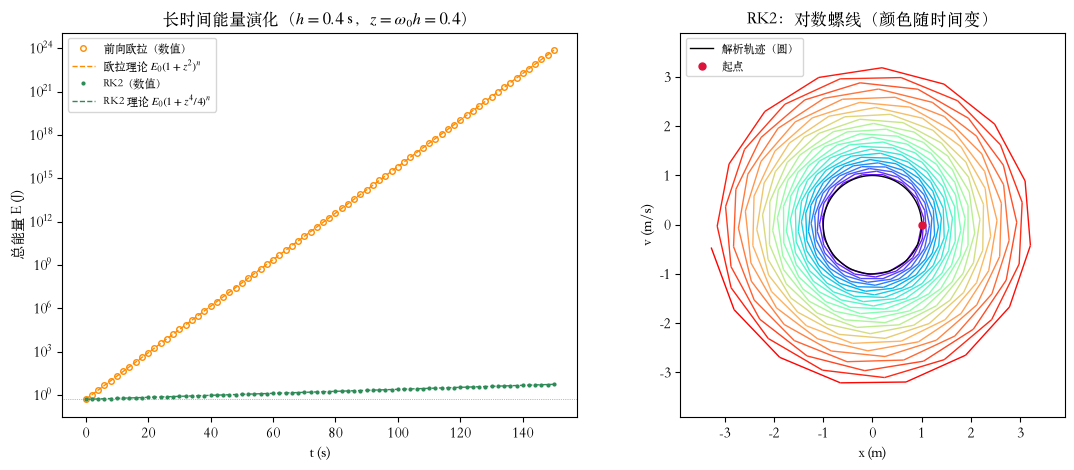

In [6]:
h_long = 0.4                  # 大步长 (s)
t_long = 150.0                # 长时间 (s)
n_long = int(t_long / h_long)
z_long = om0 * h_long

t_l, x_eu_l, v_eu_l = forward_euler_oscillator(x0, v0, k, m, h_long, n_long)
t_l, x_rk_l, v_rk_l = rk2_midpoint_oscillator(x0, v0, k, m, h_long, n_long)
E_eu_l = 0.5 * m * v_eu_l**2 + 0.5 * k * x_eu_l**2
E_rk_l = 0.5 * m * v_rk_l**2 + 0.5 * k * x_rk_l**2
steps = np.arange(n_long + 1)
E_th_eu = E0 * (1 + z_long**2) ** steps          # 欧拉解析律
E_th_rk = E0 * (1 + z_long**4 / 4) ** steps      # RK2 解析律

print(f'h = {h_long} s（z = {z_long}，每周期约 {T0 / h_long:.0f} 步），t = {t_long:.0f} s ≈ {t_long / T0:.1f} 个周期，共 {n_long} 步')
print(f'{"":18}{"RK2":>20}{"前向欧拉":>20}')
print(f'{"末放大倍数（数值）":18}{E_rk_l[-1] / E0:>20.6f}{E_eu_l[-1] / E0:>20.3e}')
print(f'{"末放大倍数（理论）":18}{(1 + z_long**4 / 4)**n_long:>20.6f}{(1 + z_long**2)**n_long:>20.3e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))

# (a) semilogy：数值曲线应严丝合缝地压在解析虚线上
ax1.semilogy(t_l, E_eu_l, 'o', color='darkorange', ms=4, mfc='none', markevery=5, label='前向欧拉（数值）')
ax1.semilogy(t_l, E_th_eu, '--', color='darkorange', lw=1, label=r'欧拉理论 $E_0(1+z^2)^n$')
ax1.semilogy(t_l, E_rk_l, '.', color='seagreen', ms=4, markevery=5, label='RK2（数值）')
ax1.semilogy(t_l, E_th_rk, '--', color='seagreen', lw=1, label=r'RK2 理论 $E_0(1+z^4/4)^n$')
ax1.axhline(E0, color='gray', lw=0.5, ls=':')
ax1.set_xlabel('t (s)')
ax1.set_ylabel('总能量 E (J)')
ax1.set_title(f'长时间能量演化（$h = {h_long}$ s，$z = \\omega_0 h = {z_long}$）')
ax1.legend(fontsize=8, loc='upper left')

# (b) RK2 的对数螺线
pts = np.array([x_rk_l, v_rk_l]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(segs, cmap='rainbow', array=np.arange(len(segs)), lw=1)
ax2.add_collection(lc)
ax2.plot(np.cos(th_c), np.sin(th_c), 'k-', lw=1, label='解析轨迹（圆）')
ax2.plot(x_rk_l[0], v_rk_l[0], 'o', color='crimson', ms=5, label='起点')
ax2.set_xlabel('x (m)')
ax2.set_ylabel('v (m/s)')
ax2.set_aspect('equal')
ax2.set_xlim(-3.9, 3.9)
ax2.set_ylim(-3.9, 3.9)
ax2.set_title('RK2：对数螺线（颜色随时间变）')
ax2.legend(fontsize=8, loc='upper left')

fig.tight_layout()
fig.savefig('outputs/4_simple_oscillator_rk2_long.pdf')
plt.show()

**读图**：

1. **左图**：两条数值曲线在跨越约 24 个数量级的纵轴上**严丝合缝地压在各自的解析虚线上**——打印显示数值末放大倍数 10.939199 对理论 10.939199，七位有效数字逐位相同。公式是精确律，不是拟合。
2. **右图**：RK2 的轨迹是缓慢外旋的**对数螺线**：每步转过恒定角度 $\arg\lambda$、半径乘恒定比例 $|\lambda|$——"伸缩 + 旋转"的几何形象。
3. **无稳定步长**：$|\lambda|^2 = 1 + z^4/4 > 1$ 对任何 $h$ 成立——RK2 对振子是无条件能量不稳定的：比欧拉法慢 $h^2$ 倍，但命运相同。非线性系统没有解析律护体——下一例单摆的能量上漂，只能靠数值观察。

## 小结与思考

- RK2 求解简谐振子**不精确**，但线性性让一切误差可解析追踪；
- 能量漂移精确律 $E_n = E_0(1+z^4/4)^n$（欧拉法 $(1+z^2)^n$）——数值逐位落在公式上；
- 周期误差 $\propto h^2$ 且与欧拉法**符号相反**（RK2 偏快、恰为一半）；
- **无稳定步长**：RK2 只把漂移率从 ∝h 降到 ∝h³，没有消除漂移；
- RK2 系列过半：常力精确（例 3）→ 线性可解析（本例）→ 非线性实战（下一例单摆）。

**思考**：

1. 把长时间模拟的 $h$ 从 0.4 减半到 0.2：左图曲线的斜率（单位时间能量增长的对数）变为几分之一？先用 $E_n = E_0(1+z^4/4)^n$ 推算，再改参数重跑验证。
2. 取 $h = 2.5$（$z > 2$，特征值实部 $1 - z^2/2 < 0$）：每一步矩阵在"伸缩 + 旋转"之外还多了一个反号。数值轨道会呈现什么图案？
3. 给振子加上阻尼力 $-\gamma v$，真实能量按 $e^{-\gamma t}$ 衰减。阻尼振子仍是线性系统——特征值方法照样适用。算一算 RK2 的 $|\lambda|$ 与 $e^{-\gamma h/2}$ 谁大：数值能量会比真实能量衰减得慢吗？（答案可能出乎意料。）